  Air Traffic MDP Simulation

[1/5] Loading TFR polygon...
  TFR has 15 vertices, centroid (25.512, -89.546).

[2/5] Loading aircraft trajectories...
  Found 11 CSV file(s).
  Loaded 11 aircraft.
       AAL1028 :  948 rows,    987 nm OD, 39 interpolated rows
        AAL917 : 1574 rows,   2278 nm OD, 162 interpolated rows
       AZU8708 : 1986 rows,   3666 nm OD, 74 interpolated rows
        AMX410 : 1586 rows,   1806 nm OD, 40 interpolated rows
       JBU1052 : 1471 rows,    537 nm OD, 1 interpolated rows
        BWA035 :  744 rows,    523 nm OD, 22 interpolated rows
       DAL1812 :  977 rows,   2096 nm OD, 47 interpolated rows
       UAL1020 :  602 rows,    706 nm OD, 25 interpolated rows
        SWG388 : 1092 rows,   1203 nm OD, 0 interpolated rows
       SWG5417 : 1131 rows,   1407 nm OD, 9 interpolated rows
        SWA219 : 1426 rows,   1246 nm OD, 50 interpolated rows
  Simulation horizon : 1986 steps.

[3/5] Training MDP policies...
  Building MDP model: |S|=800, |A|=7, K=25 sam

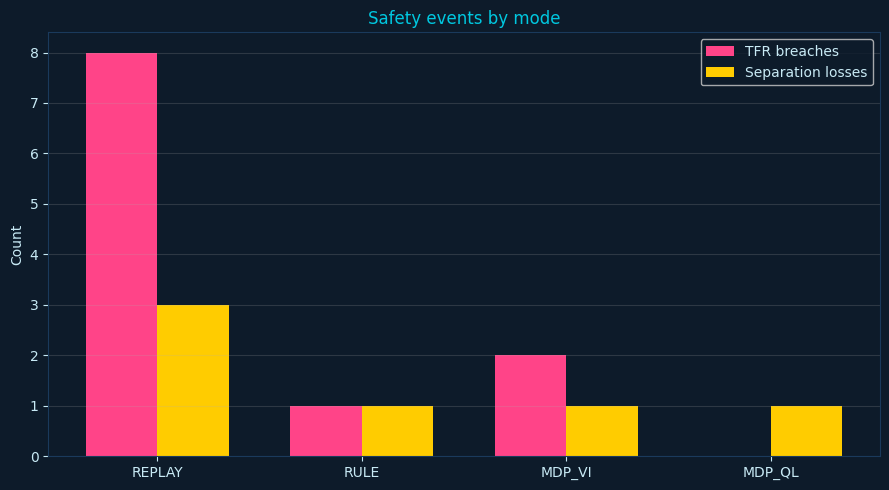

  wrote aircraft_map_replay.html  +  aircraft_3d_replay.html
  wrote aircraft_map_rule.html  +  aircraft_3d_rule.html
  wrote aircraft_map_mdp_vi.html  +  aircraft_3d_mdp_vi.html
  wrote aircraft_map_mdp_ql.html  +  aircraft_3d_mdp_ql.html


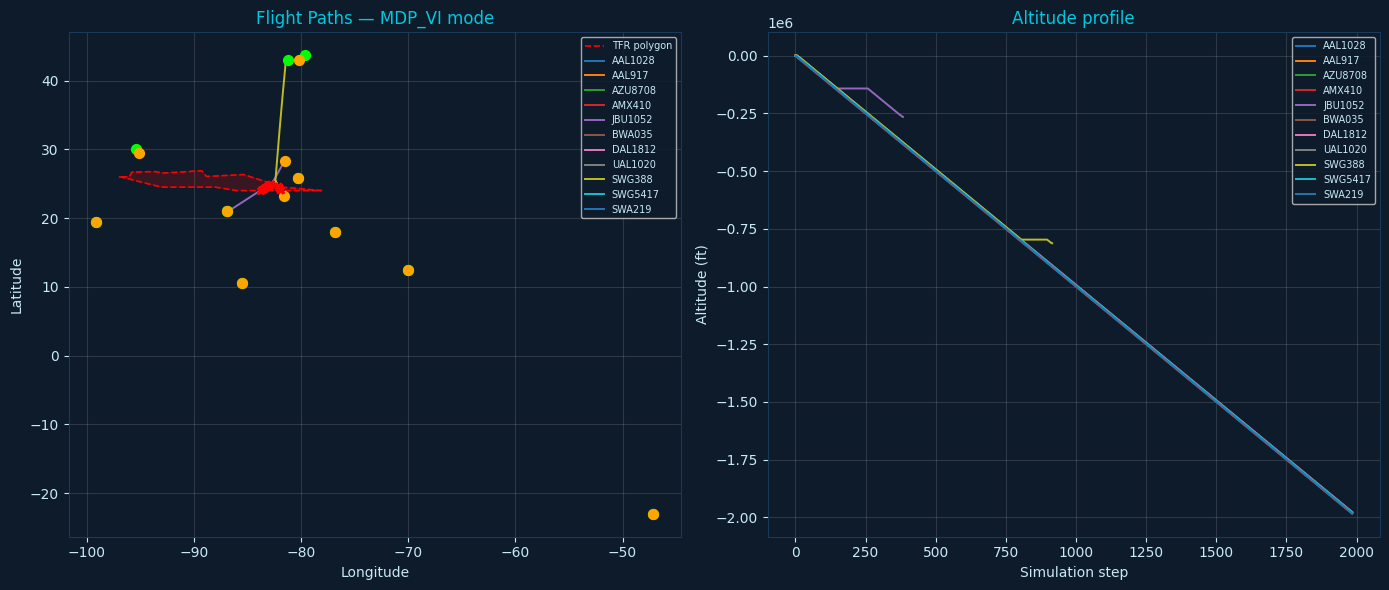

In [1]:
"""
Air Traffic MDP / POMDP Simulation
==================================
Project   : MDP/POMDP Air Traffic Navigation During Space Launch Operations
Phase     : 2 — Baseline Policies + MDP Policy + Scaling

What this file does
-------------------
Loads ADS-B trajectories (FlightRadar24 CSVs) and a polygonal TFR (the
launch-hazard area NOTAM), then simulates aircraft navigating through
the airspace under four different policies that we compare side-by-side:

    'replay'   — aircraft follow the CSV trajectory exactly.
                 Pure historical baseline. "What actually happened."
    'rule'     — hand-crafted reactive avoidance: look 20 steps ahead;
                 if the projected path enters the TFR or violates 5 nm
                 separation, turn 90° away. Otherwise fly toward the
                 destination.
    'mdp_vi'   — tabular MDP solved offline by value iteration.
                 256 discrete states × 7 actions, transitions sampled,
                 rewards hand-shaped, gamma = 0.95.
    'mdp_ql'   — same MDP solved by Q-learning over simulated rollouts
                 (epsilon-greedy, alpha=0.1, ~3000 episodes).

Why the polygon TFR
-------------------
The original code modelled the TFR as a circle. Real FAA TFRs are
*polygons* — the corners are the points published in the NOTAM. The
spreadsheet TFR_Lat_Lon.xlsx lists the 15 corners of the Gulf-of-Mexico
launch hazard area, so we wrap them in a Polygon class with proper
ray-casting point-in-polygon and signed haversine distance to the
nearest edge.

POMDP-lite (uncertainty)
------------------------
ADS-B has dead-zones. During an interpolated gap we don't know the
aircraft's true position, so we keep a Gaussian belief whose sigma
grows by speed × dt and collapses on the next real fix. Separation
thresholds are inflated by k*sigma during dropouts so the policy
stays conservative when blind.

References for the MDP design
-----------------------------
  - Bellman (1957)                — value iteration / Bellman backups
  - Sutton & Barto (2018)         — Reinforcement Learning textbook
  - Kochenderfer (2015), ch. 11   — Decision Making Under Uncertainty,
                                    ACAS-X collision avoidance MDP
  - ICAO Doc 4444                 — radar separation minimum: 3 nm
  - FAA Order 7110.65             — conflict alert at ~5 nm warning band

Author: project team (2026 cohort)
"""

# =============================================================================
# 1. IMPORTS & CONFIGURATION
# =============================================================================
import os
import math
import random
import webbrowser
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from mesa import Agent, Model
from mesa.time import BaseScheduler


# ──────────────────── PATHS (edit these for your machine) ────────────────────
DATA_FOLDER = r"C:\Users\Dev Sharma\Desktop\EREU\Datasets\Validation data (FlightRader24)"
TFR_VERTEX_FILE = r"C:\Users\Dev Sharma\Desktop\EREU\tfr\TFR_Lat_Lon.xlsx"

# ──────────────────── ENVIRONMENT CONSTANTS ────────────────────
GAP_THRESHOLD_SECONDS    = 60     # interpolate ADS-B gaps longer than this
STEP_DURATION_SECONDS    = 30     # one simulation tick = 30 s of real flight
CONFLICT_LOOKAHEAD_STEPS = 20     # how far ahead the rule policy peeks
SEPARATION_HARD_NM       = 3.0    # ICAO radar minimum
SEPARATION_WARN_NM       = 5.0    # FAA conflict-alert band
SEPARATION_AWARE_NM      = 10.0   # awareness band for state encoding

# ──────────────────── MDP HYPERPARAMETERS ────────────────────
MDP_GAMMA           = 0.95      # discount
MDP_VI_TOL          = 1e-3      # value-iteration convergence tolerance
MDP_VI_MAX_ITERS    = 500
MDP_T_SAMPLES       = 25        # samples per (s,a) for empirical transition
MDP_QL_EPISODES     = 3000      # Q-learning training episodes
MDP_QL_STEPS        = 80        # max steps per training episode
MDP_QL_ALPHA        = 0.1       # learning rate
MDP_QL_EPS_START    = 1.0       # epsilon-greedy schedule
MDP_QL_EPS_END      = 0.05
MDP_RNG_SEED        = 42        # reproducible MDP training


# =============================================================================
# 2. GEOMETRY HELPERS
# =============================================================================
# All distances are in nautical miles (nm). 1 nm ≈ 1.852 km.
# Bearings are compass-style: 0° = North, 90° = East, 180° = South, 270° = West.

EARTH_RADIUS_NM = 3440.0


def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance between two lat/lon points, in nm."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * EARTH_RADIUS_NM * np.arcsin(np.sqrt(a))


def bearing_between(lat1, lon1, lat2, lon2):
    """Compass bearing FROM (lat1, lon1) TO (lat2, lon2), degrees."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    return (np.degrees(np.arctan2(x, y)) + 360.0) % 360.0


def move_by_heading(lat, lon, heading_deg, speed_kts, time_seconds):
    """
    Dead reckoning. Given a position, compass heading and speed, returns
    the new position after flying for `time_seconds`.
    """
    distance_nm = (speed_kts / 3600.0) * time_seconds  # speed in nm/s × s = nm
    angular_dist = distance_nm / EARTH_RADIUS_NM

    lat_rad = math.radians(lat)
    lon_rad = math.radians(lon)
    hdg_rad = math.radians(heading_deg)

    new_lat = math.asin(
        math.sin(lat_rad) * math.cos(angular_dist)
        + math.cos(lat_rad) * math.sin(angular_dist) * math.cos(hdg_rad)
    )
    new_lon = lon_rad + math.atan2(
        math.sin(hdg_rad) * math.sin(angular_dist) * math.cos(lat_rad),
        math.cos(angular_dist) - math.sin(lat_rad) * math.sin(new_lat),
    )
    return math.degrees(new_lat), math.degrees(new_lon)


def relative_bearing(my_heading_deg, target_bearing_deg):
    """
    Where the target sits relative to my nose. Returned in the range
    (-180, +180]. Positive = right of nose, negative = left of nose.
    """
    diff = (target_bearing_deg - my_heading_deg + 540.0) % 360.0 - 180.0
    return diff


# =============================================================================
# 3. POLYGONAL TFR
# =============================================================================
class TFRZone:
    """
    Polygonal Temporary Flight Restriction.

    Loaded from a spreadsheet of (lat, lon) corners. We sort the corners
    counter-clockwise around the centroid so the row order in the Excel
    doesn't matter — angle-sort produces a non-self-intersecting outline
    for star-convex shapes (which Gulf-of-Mexico hazard areas are in
    practice).

    contains(lat, lon)    : True if the point is INSIDE the polygon (violation)
    distance_to_edge(...) : Signed nm distance to the nearest edge.
                             Negative → inside (violating). Positive → safe.
    """

    def __init__(self, vertices_lat, vertices_lon):
        # Force counter-clockwise angle order
        lat = np.asarray(vertices_lat, dtype=float)
        lon = np.asarray(vertices_lon, dtype=float)
        self.centroid_lat = float(lat.mean())
        self.centroid_lon = float(lon.mean())
        ang = np.arctan2(lat - self.centroid_lat, lon - self.centroid_lon)
        order = np.argsort(ang)
        self.lats = lat[order]
        self.lons = lon[order]
        self.n_vertices = len(self.lats)

    # ── Public API ────────────────────────────────────────────────────
    def contains(self, lat, lon):
        """Ray-casting point-in-polygon. Casts a ray east; counts crossings."""
        return self._ray_cast(lat, lon)

    def distance_to_edge(self, lat, lon):
        """
        Signed haversine distance to the nearest polygon edge.
        Inside  → negative   (violating, magnitude = distance to perimeter)
        Outside → positive   (safe,      magnitude = distance to perimeter)
        """
        d = self._min_edge_distance(lat, lon)
        return -d if self.contains(lat, lon) else d

    # ── Internals ─────────────────────────────────────────────────────
    def _ray_cast(self, lat, lon):
        n = self.n_vertices
        inside = False
        j = n - 1
        for i in range(n):
            yi, xi = self.lats[i], self.lons[i]
            yj, xj = self.lats[j], self.lons[j]
            if ((yi > lat) != (yj > lat)) and (
                lon < (xj - xi) * (lat - yi) / ((yj - yi) + 1e-12) + xi
            ):
                inside = not inside
            j = i
        return inside

    def _min_edge_distance(self, lat, lon):
        """
        Convert each edge + the query point to local equirectangular nm
        coordinates and use plane-geometry segment distance. Accurate to
        sub-nm at the latitudes we care about (24°–27° N).
        """
        # Reference frame at TFR centroid
        rlat = self.centroid_lat
        x0 = self._lon_to_x(lon, rlat)
        y0 = self._lat_to_y(lat)
        xs = self._lon_to_x(self.lons, rlat)
        ys = self._lat_to_y(self.lats)
        n = self.n_vertices
        best = float("inf")
        for i in range(n):
            j = (i + 1) % n
            d = self._point_to_segment(x0, y0, xs[i], ys[i], xs[j], ys[j])
            if d < best:
                best = d
        return best

    @staticmethod
    def _lon_to_x(lon_deg, ref_lat_deg):
        return np.radians(lon_deg) * EARTH_RADIUS_NM * math.cos(math.radians(ref_lat_deg))

    @staticmethod
    def _lat_to_y(lat_deg):
        return np.radians(lat_deg) * EARTH_RADIUS_NM

    @staticmethod
    def _point_to_segment(px, py, ax, ay, bx, by):
        abx, aby = bx - ax, by - ay
        apx, apy = px - ax, py - ay
        denom = abx * abx + aby * aby
        t = 0.0 if denom == 0 else max(0.0, min(1.0, (apx * abx + apy * aby) / denom))
        cx = ax + t * abx
        cy = ay + t * aby
        return math.hypot(px - cx, py - cy)


def load_tfr_from_excel(path):
    """
    The spreadsheet has Lat_dd / Lon_dd columns (decimal degrees).
    Falls back to a default circle around Boca Chica if the file
    can't be read — keeps the demo runnable even without the data.
    """
    try:
        df = pd.read_excel(path)
        return TFRZone(df["Lat_dd"].tolist(), df["Lon_dd"].tolist())
    except Exception as exc:
        print(f"  ! Could not load TFR file ({exc}); falling back to a 30 nm "
              f"circular TFR at Boca Chica.")
        # Approximate a circle with 36 vertices
        cx_lat, cx_lon, r_nm = 25.997, -97.156, 30.0
        ang = np.linspace(0, 2 * np.pi, 36, endpoint=False)
        lats = cx_lat + (r_nm / 60.0) * np.sin(ang)
        lons = cx_lon + (r_nm / 60.0) * np.cos(ang) / math.cos(math.radians(cx_lat))
        return TFRZone(lats, lons)


# =============================================================================
# 4. ADS-B DATA LOADING (with gap fill)
# =============================================================================
def fill_gaps(df, gap_threshold_seconds=60):
    """
    ADS-B receivers have blind spots. Linearly interpolate at 30 s
    cadence through any gap > threshold. Each synthetic row is flagged
    with `interpolated=True` so downstream code (and the belief filter)
    knows that position is uncertain.
    """
    rows = []
    for i in range(len(df) - 1):
        rows.append(df.iloc[i].to_dict())
        gap = (df["UTC"].iloc[i + 1] - df["UTC"].iloc[i]).total_seconds()
        if gap > gap_threshold_seconds:
            n_fill = int(gap / STEP_DURATION_SECONDS) - 1
            for step in range(1, n_fill + 1):
                frac = (step * STEP_DURATION_SECONDS) / gap
                f = df.iloc[i].to_dict()
                f["UTC"] = df["UTC"].iloc[i] + pd.Timedelta(seconds=step * STEP_DURATION_SECONDS)
                for col in ("lat", "lon", "Altitude", "Speed"):
                    f[col] = df[col].iloc[i] + frac * (df[col].iloc[i + 1] - df[col].iloc[i])
                f["interpolated"] = True
                rows.append(f)
    rows.append(df.iloc[-1].to_dict())
    out = pd.DataFrame(rows).reset_index(drop=True)
    out["interpolated"] = out.get("interpolated", False).fillna(False)
    return out


def load_aircraft_data(folder_path):
    """
    Returns { callsign : trajectory_dataframe }.
    Handles both single-aircraft files and combined dumps.
    """
    aircraft = {}
    if not os.path.isdir(folder_path):
        print(f"  ! Folder not found: {folder_path}")
        return aircraft

    csvs = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
    print(f"  Found {len(csvs)} CSV file(s).")

    for filename in csvs:
        path = os.path.join(folder_path, filename)
        df = pd.read_csv(path)
        df["UTC"] = pd.to_datetime(df["UTC"])
        df[["lat", "lon"]] = df["Position"].str.split(",", expand=True).astype(float)
        df["interpolated"] = False

        if "Callsign" in df.columns:
            for callsign, group in df.groupby("Callsign"):
                cleaned = fill_gaps(group.sort_values("UTC").reset_index(drop=True))
                aircraft[callsign] = cleaned
        else:
            callsign = filename.replace(".csv", "")
            cleaned = fill_gaps(df.sort_values("UTC").reset_index(drop=True))
            aircraft[callsign] = cleaned
    return aircraft


# =============================================================================
# 5. BELIEF STATE (POMDP-lite for ADS-B dropouts)
# =============================================================================
class BeliefState:
    """
    Tiny Gaussian filter over aircraft position. We keep a single sigma
    (in nm) that grows when the position is interpolated and snaps back
    on a real fix. This gives the policy a confidence band without
    needing a full particle filter.

        update(observed=True)  → sigma decays toward sigma_min
        update(observed=False) → sigma += speed * dt
    """

    SIGMA_MIN = 0.05            # nm — clean ADS-B fix uncertainty
    SIGMA_MAX = 5.0             # nm — cap so the policy doesn't explode
    DECAY     = 0.4             # how fast sigma shrinks on a real fix

    def __init__(self):
        self.sigma_nm = self.SIGMA_MIN

    def update(self, observed: bool, speed_kts: float):
        if observed:
            self.sigma_nm = max(self.SIGMA_MIN,
                                self.sigma_nm * self.DECAY)
        else:
            growth = (speed_kts / 3600.0) * STEP_DURATION_SECONDS
            self.sigma_nm = min(self.SIGMA_MAX, self.sigma_nm + growth)

    def inflated_sep(self, base_nm: float, k: float = 1.5):
        """Pad a separation threshold with k·sigma when uncertain."""
        return base_nm + k * self.sigma_nm


# =============================================================================
# 6. MDP DEFINITION (states, actions, rewards)
# =============================================================================
# The state is a discrete tuple of five features:
#
#   tfr_dist_bin      0=INSIDE, 1=VERY_CLOSE(<5nm), 2=CLOSE(<15nm),
#                     3=NEAR(<30nm), 4=SAFE
#   dest_bearing_bin  0=AHEAD, 1=RIGHT, 2=LEFT, 3=BEHIND
#   tfr_threat        0=NO, 1=YES   (lookahead conflict in 20 steps)
#   sep_bin           0=COLLISION(<3), 1=WARNING(<5), 2=AWARE(<10), 3=CLEAR
#   threat_bear_bin   0=NA (no threat), 1=AHEAD, 2=RIGHT, 3=LEFT, 4=BEHIND
#
# Total: 5·4·2·4·5 = 800 states.

ACTIONS = (
    "MAINTAIN",
    "TURN_LEFT_20",
    "TURN_RIGHT_20",
    "TURN_LEFT_45",
    "TURN_RIGHT_45",
    "CLIMB",
    "DESCEND",
)
ACTION_TO_IDX = {a: i for i, a in enumerate(ACTIONS)}


def discretize_state(tfr_dist_nm: float,
                     dest_rel_bearing: float,
                     tfr_threat: bool,
                     sep_min_nm: float,
                     threat_rel_bearing: Optional[float]) -> Tuple[int, int, int, int, int]:
    """Map continuous features → the 5-tuple discrete state."""
    # TFR distance bins (signed: negative = inside)
    if tfr_dist_nm < 0:                 tfr_b = 0
    elif tfr_dist_nm < 5:               tfr_b = 1
    elif tfr_dist_nm < 15:              tfr_b = 2
    elif tfr_dist_nm < 30:              tfr_b = 3
    else:                               tfr_b = 4

    # Destination relative bearing (-180, +180]
    db = dest_rel_bearing
    if   -22.5 <= db <= 22.5:           dest_b = 0  # AHEAD
    elif   22.5 < db <= 157.5:          dest_b = 1  # RIGHT
    elif -157.5 <= db < -22.5:          dest_b = 2  # LEFT
    else:                               dest_b = 3  # BEHIND

    threat_b = 1 if tfr_threat else 0

    if   sep_min_nm < SEPARATION_HARD_NM:     sep_b = 0
    elif sep_min_nm < SEPARATION_WARN_NM:     sep_b = 1
    elif sep_min_nm < SEPARATION_AWARE_NM:    sep_b = 2
    else:                                     sep_b = 3

    if threat_rel_bearing is None or sep_b == 3:
        tb = 0
    else:
        rb = threat_rel_bearing
        if   -22.5 <= rb <= 22.5:       tb = 1  # AHEAD
        elif   22.5 < rb <= 157.5:      tb = 2  # RIGHT
        elif -157.5 <= rb < -22.5:      tb = 3  # LEFT
        else:                           tb = 4  # BEHIND
    return (tfr_b, dest_b, threat_b, sep_b, tb)


def all_states():
    return [(t, d, h, s, tb)
            for t in range(5) for d in range(4) for h in range(2)
            for s in range(4) for tb in range(5)]


# ────────────── REWARD FUNCTION ──────────────
# Justifications:
#   TFR breach      :  -2000   — by far the worst outcome (FAA penalty class)
#   Sep collision   :  -1000   — loss of separation is also catastrophic
#   Sep warning     :   -120   — discourages flirting with 5 nm boundary
#   Step cost       :     -1   — encourages reaching destination
#   Heading aligned :   +5     — shaping reward for progress
#   Action cost     :  -1/-3/-2 (small turn / large turn / altitude change)
#   Reach dest      :   +400
def reward(state, action) -> float:
    tfr_b, dest_b, threat_b, sep_b, _ = state
    r = -1.0  # step cost

    if tfr_b == 0:                  r += -2000.0
    elif tfr_b == 1 and threat_b:   r += -150.0     # imminent breach risk
    elif threat_b:                  r += -40.0     # mid-range warning

    if sep_b == 0:                  r += -1000.0
    elif sep_b == 1:                r += -120.0

    if dest_b == 0:                 r += 5.0       # going the right way
    elif dest_b == 3:               r += -3.0      # going the wrong way

    if action in ("TURN_LEFT_20", "TURN_RIGHT_20"):  r += -1.0
    elif action in ("TURN_LEFT_45", "TURN_RIGHT_45"): r += -3.0
    elif action in ("CLIMB", "DESCEND"):              r += -2.0
    return r


# ────────────── TRANSITION MODEL (sampled) ──────────────
# We don't know T(s, a, s') in closed form because each discrete state
# corresponds to a continuum of physical states. So we *sample*: for
# each (s, a) we draw K representative continuous states, apply the
# action, and tally where we land. This is a standard model-based RL
# pattern (Sutton & Barto §8).
@dataclass
class _Sample:
    """A representative continuous state used for transition sampling."""
    lat: float
    lon: float
    heading: float
    speed: float
    altitude: float
    dest_lat: float
    dest_lon: float
    other_lat: Optional[float]
    other_lon: Optional[float]


def _draw_sample_for_bin(state, tfr: TFRZone, rng) -> _Sample:
    """
    Generate a plausible continuous state that maps to discrete `state`.
    Geometry is anchored near the TFR centroid so the same MDP is valid
    regardless of which TFR shape is loaded.
    """
    tfr_b, dest_b, threat_b, sep_b, tb = state
    cx_lat, cx_lon = tfr.centroid_lat, tfr.centroid_lon

    # Pick a distance to the TFR matching the bin
    if   tfr_b == 0: d = rng.uniform(0.5, 8.0); inside = True
    elif tfr_b == 1: d = rng.uniform(0.5, 4.5); inside = False
    elif tfr_b == 2: d = rng.uniform(5.5, 14.0); inside = False
    elif tfr_b == 3: d = rng.uniform(16.0, 28.0); inside = False
    else:            d = rng.uniform(35.0, 60.0); inside = False

    # Pick a bearing radially out of the centroid; convert to lat/lon
    radial = rng.uniform(0, 360)
    if inside:
        # Just put the aircraft slightly inside the polygon
        lat, lon = move_by_heading(cx_lat, cx_lon, radial, 1.0, 0)
        # nudge it a little
        lat += rng.uniform(-0.05, 0.05)
        lon += rng.uniform(-0.05, 0.05)
    else:
        # Place it outside by walking radially out
        lat, lon = cx_lat, cx_lon
        # Move out to the chosen distance via a unit-speed walk
        # (1 hour at d kts → d nm)
        lat, lon = move_by_heading(cx_lat, cx_lon, radial, d, 3600)

    heading = rng.uniform(0, 360)
    speed = rng.uniform(360, 480)             # cruise jet speeds
    altitude = rng.uniform(28000, 38000)

    # Destination bearing → derive a destination location ~150 nm away
    dest_rel = {0: rng.uniform(-22.5, 22.5),
                1: rng.uniform(22.5, 157.5),
                2: rng.uniform(-157.5, -22.5),
                3: rng.uniform(157.5, 202.5)}[dest_b]
    dest_bearing = (heading + dest_rel) % 360
    dest_lat, dest_lon = move_by_heading(lat, lon, dest_bearing, 480.0, 3600 * 0.5)

    # Other aircraft for the separation / threat bin
    if sep_b == 3:
        return _Sample(lat, lon, heading, speed, altitude,
                       dest_lat, dest_lon, None, None)

    other_dist = {0: rng.uniform(0.5, 2.5),
                  1: rng.uniform(3.2, 4.8),
                  2: rng.uniform(5.5, 9.5)}[sep_b]
    other_rel = {1: rng.uniform(-22.5, 22.5),
                 2: rng.uniform(22.5, 157.5),
                 3: rng.uniform(-157.5, -22.5),
                 4: rng.uniform(157.5, 202.5)}.get(tb, rng.uniform(0, 360))
    other_bearing = (heading + other_rel) % 360
    other_lat, other_lon = move_by_heading(lat, lon, other_bearing,
                                           other_dist, 3600)
    return _Sample(lat, lon, heading, speed, altitude, dest_lat, dest_lon,
                   other_lat, other_lon)


def _apply_action(sample: _Sample, action: str) -> _Sample:
    """Apply an action to a sample for one tick."""
    h = sample.heading
    speed = sample.speed
    alt = sample.altitude
    if   action == "TURN_LEFT_20":   h = (h - 20) % 360
    elif action == "TURN_RIGHT_20":  h = (h + 20) % 360
    elif action == "TURN_LEFT_45":   h = (h - 45) % 360
    elif action == "TURN_RIGHT_45":  h = (h + 45) % 360
    elif action == "CLIMB":          alt += 1000
    elif action == "DESCEND":        alt -= 1000

    new_lat, new_lon = move_by_heading(sample.lat, sample.lon, h, speed,
                                       STEP_DURATION_SECONDS)
    # Other aircraft drifts with constant velocity (assume ~level flight)
    if sample.other_lat is not None:
        # Random-ish bearing for the other a/c — held over the tick
        # (we don't track its heading; just nudge it)
        ol, on = sample.other_lat, sample.other_lon
        ol += np.random.uniform(-0.01, 0.01)
        on += np.random.uniform(-0.01, 0.01)
    else:
        ol, on = None, None
    return _Sample(new_lat, new_lon, h, speed, alt,
                   sample.dest_lat, sample.dest_lon, ol, on)


def _classify(sample: _Sample, tfr: TFRZone) -> Tuple[int, int, int, int, int]:
    """Map a continuous sample back to a discrete state tuple."""
    tfr_dist = tfr.distance_to_edge(sample.lat, sample.lon)
    dest_brg = bearing_between(sample.lat, sample.lon,
                               sample.dest_lat, sample.dest_lon)
    dest_rel = relative_bearing(sample.heading, dest_brg)

    # Cheap lookahead threat estimate: project 10 ticks straight, look for entry
    threat = False
    lat, lon = sample.lat, sample.lon
    for _ in range(10):
        lat, lon = move_by_heading(lat, lon, sample.heading, sample.speed,
                                   STEP_DURATION_SECONDS)
        if tfr.contains(lat, lon):
            threat = True
            break

    if sample.other_lat is None:
        sep = 999.0
        threat_rel = None
    else:
        sep = haversine(sample.lat, sample.lon, sample.other_lat, sample.other_lon)
        brg = bearing_between(sample.lat, sample.lon,
                              sample.other_lat, sample.other_lon)
        threat_rel = relative_bearing(sample.heading, brg)

    return discretize_state(tfr_dist, dest_rel, threat, sep, threat_rel)


# =============================================================================
# 7. VALUE-ITERATION SOLVER
# =============================================================================
class ValueIterationSolver:
    """
    Tabular value iteration. We build T and R once by Monte-Carlo
    sampling, then run synchronous Bellman backups until V converges.
    """

    def __init__(self, tfr: TFRZone, gamma=MDP_GAMMA, n_samples=MDP_T_SAMPLES,
                 seed=MDP_RNG_SEED):
        self.tfr = tfr
        self.gamma = gamma
        self.n_samples = n_samples
        self.rng = random.Random(seed)
        self.states = all_states()
        self.state_idx = {s: i for i, s in enumerate(self.states)}
        self.V: Dict[Tuple, float] = {s: 0.0 for s in self.states}
        self.policy: Dict[Tuple, str] = {s: "MAINTAIN" for s in self.states}
        self.T: Dict[Tuple, Dict[str, Dict[Tuple, float]]] = {}
        self.R: Dict[Tuple, Dict[str, float]] = {}

    # ── Build empirical transition / reward tables ──
    def build_model(self):
        print(f"  Building MDP model: |S|={len(self.states)}, |A|={len(ACTIONS)}, "
              f"K={self.n_samples} samples per (s,a)…")
        for s in self.states:
            self.T[s] = {}
            self.R[s] = {}
            for a in ACTIONS:
                counts: Dict[Tuple, int] = defaultdict(int)
                r_sum = 0.0
                for _ in range(self.n_samples):
                    sample = _draw_sample_for_bin(s, self.tfr, self.rng)
                    next_sample = _apply_action(sample, a)
                    s_next = _classify(next_sample, self.tfr)
                    counts[s_next] += 1
                    r_sum += reward(s_next, a)
                total = float(sum(counts.values()))
                self.T[s][a] = {sn: c / total for sn, c in counts.items()}
                self.R[s][a] = r_sum / self.n_samples

    # ── Bellman backups ──
    def solve(self):
        for it in range(MDP_VI_MAX_ITERS):
            delta = 0.0
            new_V: Dict[Tuple, float] = {}
            for s in self.states:
                best_q = -float("inf")
                best_a = "MAINTAIN"
                for a in ACTIONS:
                    q = self.R[s][a]
                    for sn, p in self.T[s][a].items():
                        q += self.gamma * p * self.V[sn]
                    if q > best_q:
                        best_q = q
                        best_a = a
                new_V[s] = best_q
                self.policy[s] = best_a
                delta = max(delta, abs(best_q - self.V[s]))
            self.V = new_V
            if delta < MDP_VI_TOL:
                print(f"  Value iteration converged in {it + 1} iterations "
                      f"(Δ={delta:.2e}).")
                return
        print(f"  Value iteration hit max iters ({MDP_VI_MAX_ITERS}).")

    def act(self, state) -> str:
        return self.policy.get(state, "MAINTAIN")


# =============================================================================
# 8. Q-LEARNING SOLVER
# =============================================================================
class QLearningSolver:
    """
    Tabular Q-learning. Trained on simulated rollouts in the same
    sampling environment used for VI, but model-free — the agent
    bootstraps its own value estimate from temporal-difference targets.
    """

    def __init__(self, tfr: TFRZone, gamma=MDP_GAMMA, alpha=MDP_QL_ALPHA,
                 episodes=MDP_QL_EPISODES, max_steps=MDP_QL_STEPS,
                 eps_start=MDP_QL_EPS_START, eps_end=MDP_QL_EPS_END,
                 seed=MDP_RNG_SEED + 1):
        self.tfr = tfr
        self.gamma = gamma
        self.alpha = alpha
        self.episodes = episodes
        self.max_steps = max_steps
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.rng = random.Random(seed)
        self.states = all_states()
        self.Q: Dict[Tuple, Dict[str, float]] = {
            s: {a: 0.0 for a in ACTIONS} for s in self.states
        }

    def _epsilon(self, ep):
        return self.eps_end + (self.eps_start - self.eps_end) * \
               max(0.0, 1.0 - ep / self.episodes)

    def _greedy(self, s):
        return max(self.Q[s], key=self.Q[s].get)

    def train(self):
        print(f"  Q-learning training: {self.episodes} episodes × "
              f"{self.max_steps} steps…")
        for ep in range(self.episodes):
            eps = self._epsilon(ep)
            # Random initial bin
            sample = _draw_sample_for_bin(self.rng.choice(self.states),
                                          self.tfr, self.rng)
            s = _classify(sample, self.tfr)
            for _ in range(self.max_steps):
                a = (self.rng.choice(ACTIONS) if self.rng.random() < eps
                     else self._greedy(s))
                next_sample = _apply_action(sample, a)
                s_next = _classify(next_sample, self.tfr)
                r = reward(s_next, a)
                td_target = r + self.gamma * max(self.Q[s_next].values())
                self.Q[s][a] += self.alpha * (td_target - self.Q[s][a])
                sample = next_sample
                s = s_next
                if s[0] == 0 or s[3] == 0:    # absorbing-ish: terminate on breach
                    break
        print("  Q-learning training complete.")

    def act(self, state) -> str:
        if state not in self.Q:
            return "MAINTAIN"
        return max(self.Q[state], key=self.Q[state].get)


# =============================================================================
# 9. AIRCRAFT AGENT
# =============================================================================
class AircraftAgent(Agent):
    """
    One aircraft. Steps under one of four modes:

      replay : faithful CSV playback
      rule   : reactive turn-90° avoidance
      mdp_vi : tabular value-iteration policy
      mdp_ql : tabular Q-learning policy
    """

    def __init__(self, unique_id, model, trajectory, mode="replay"):
        super().__init__(unique_id, model)
        self.trajectory = trajectory
        self.step_index = 0
        self.mode = mode

        # Initial physical state from row 0
        row0 = trajectory.iloc[0]
        self.lat = float(row0["lat"])
        self.lon = float(row0["lon"])
        self.altitude = float(row0["Altitude"])
        self.speed = float(row0["Speed"])
        if len(trajectory) > 1:
            r1 = trajectory.iloc[1]
            self.heading = bearing_between(row0["lat"], row0["lon"],
                                           r1["lat"], r1["lon"])
        else:
            self.heading = float(row0.get("Direction", 0))

        last = trajectory.iloc[-1]
        self.destination_lat = float(last["lat"])
        self.destination_lon = float(last["lon"])

        self.nominal_altitude = float(trajectory["Altitude"].mean())
        self.nominal_speed = float(trajectory["Speed"].mean())

        # Avoidance bookkeeping (rule mode)
        self.is_avoiding = False
        self.avoidance_steps_remaining = 0
        self.avoidance_action = None

        # POMDP-lite belief
        self.belief = BeliefState()

        # Status flags
        self.finished = False
        self.in_tfr = False           # ← new tag for visualization

        # History (used everywhere downstream — never the raw CSV)
        self.history_lat = [self.lat]
        self.history_lon = [self.lon]
        self.history_altitude = [self.altitude]
        self.history_time = [0]
        self.history_in_tfr = [False]
        self.history_sigma = [self.belief.sigma_nm]
        self.history_action = ["INIT"]

    # ─────────────────────────────────────────────────────────────────
    # Conflict prediction (used by the rule policy)
    # ─────────────────────────────────────────────────────────────────
    def _predict(self, steps_ahead):
        lat, lon = self.lat, self.lon
        for _ in range(steps_ahead):
            lat, lon = move_by_heading(lat, lon, self.heading,
                                       self.speed, STEP_DURATION_SECONDS)
        return lat, lon

    def tfr_conflict_ahead(self):
        for k in range(1, CONFLICT_LOOKAHEAD_STEPS + 1):
            lat, lon = self._predict(k)
            if self.model.tfr.contains(lat, lon):
                return True
        return False

    def separation_threats(self):
        threats = []
        thresh = self.belief.inflated_sep(SEPARATION_WARN_NM)
        for other in self.model.aircraft_agents:
            if other.unique_id == self.unique_id or other.finished:
                continue
            for k in range(1, CONFLICT_LOOKAHEAD_STEPS + 1):
                a, b = self._predict(k)
                c, d = other._predict(k)
                if haversine(a, b, c, d) < thresh:
                    threats.append(other)
                    break
        return threats

    def _heading_away_from(self, lat, lon):
        return (bearing_between(self.lat, self.lon, lat, lon) + 90) % 360

    # ─────────────────────────────────────────────────────────────────
    # Mode-specific step functions
    # ─────────────────────────────────────────────────────────────────
    def _step_replay(self):
        if self.step_index < len(self.trajectory) - 1:
            self.step_index += 1
            row = self.trajectory.iloc[self.step_index]
            self.heading = bearing_between(self.lat, self.lon,
                                           float(row["lat"]), float(row["lon"]))
            self.lat = float(row["lat"])
            self.lon = float(row["lon"])
            self.altitude = float(row["Altitude"])
            self.speed = float(row["Speed"])
            self.belief.update(observed=not bool(row.get("interpolated", False)),
                               speed_kts=self.speed)
            return "REPLAY"
        self.finished = True
        return "DONE"

    def _step_rule(self):
        if haversine(self.lat, self.lon, self.destination_lat,
                     self.destination_lon) < 10:
            self.finished = True
            return "DONE"

        if self.is_avoiding and self.avoidance_steps_remaining > 0:
            self.avoidance_steps_remaining -= 1
            action = f"AVOID_{self.avoidance_action}"
        elif self.tfr_conflict_ahead():
            self.is_avoiding = True
            self.avoidance_steps_remaining = 15
            self.avoidance_action = "TFR"
            self.heading = self._heading_away_from(self.model.tfr.centroid_lat,
                                                   self.model.tfr.centroid_lon)
            action = "AVOID_TFR"
        else:
            threats = self.separation_threats()
            if threats:
                t = threats[0]
                self.is_avoiding = True
                self.avoidance_steps_remaining = 10
                self.avoidance_action = "SEP"
                self.heading = self._heading_away_from(t.lat, t.lon)
                action = "AVOID_SEP"
            else:
                self.is_avoiding = False
                self.heading = bearing_between(self.lat, self.lon,
                                               self.destination_lat,
                                               self.destination_lon)
                action = "DIRECT"

        self.lat, self.lon = move_by_heading(self.lat, self.lon, self.heading,
                                             self.speed, STEP_DURATION_SECONDS)
        self.belief.update(observed=True, speed_kts=self.speed)
        return action

    def _step_mdp(self, solver):
        if haversine(self.lat, self.lon, self.destination_lat,
                     self.destination_lon) < 10:
            self.finished = True
            return "DONE"

        # Build current discrete state
        tfr_dist = self.model.tfr.distance_to_edge(self.lat, self.lon)
        dest_brg = bearing_between(self.lat, self.lon,
                                   self.destination_lat, self.destination_lon)
        dest_rel = relative_bearing(self.heading, dest_brg)

        threats = self.separation_threats()
        if threats:
            t = threats[0]
            sep = haversine(self.lat, self.lon, t.lat, t.lon)
            tbrg = bearing_between(self.lat, self.lon, t.lat, t.lon)
            t_rel = relative_bearing(self.heading, tbrg)
        else:
            sep = 999.0
            t_rel = None

        s = discretize_state(tfr_dist, dest_rel,
                             tfr_threat=self.tfr_conflict_ahead(),
                             sep_min_nm=sep,
                             threat_rel_bearing=t_rel)
        action = solver.act(s)

        # Apply action to physical state
        if   action == "TURN_LEFT_20":  self.heading = (self.heading - 20) % 360
        elif action == "TURN_RIGHT_20": self.heading = (self.heading + 20) % 360
        elif action == "TURN_LEFT_45":  self.heading = (self.heading - 45) % 360
        elif action == "TURN_RIGHT_45": self.heading = (self.heading + 45) % 360
        elif action == "CLIMB":         self.altitude += 1000
        elif action == "DESCEND":       self.altitude -= 1000

        # If MAINTAIN and we're on a clear path, gently nudge toward destination
        if action == "MAINTAIN" and tfr_dist > 30 and sep > SEPARATION_AWARE_NM:
            target = bearing_between(self.lat, self.lon,
                                     self.destination_lat, self.destination_lon)
            # rotate up to 5° per tick toward destination
            diff = relative_bearing(self.heading, target)
            self.heading = (self.heading + max(-5, min(5, diff))) % 360

        self.lat, self.lon = move_by_heading(self.lat, self.lon, self.heading,
                                             self.speed, STEP_DURATION_SECONDS)
        self.belief.update(observed=True, speed_kts=self.speed)
        return action

    # ─────────────────────────────────────────────────────────────────
    # Mesa hook
    # ─────────────────────────────────────────────────────────────────
    def step(self):
        if self.finished:
            return

        if   self.mode == "replay": action = self._step_replay()
        elif self.mode == "rule":   action = self._step_rule()
        elif self.mode == "mdp_vi": action = self._step_mdp(self.model.vi_solver)
        elif self.mode == "mdp_ql": action = self._step_mdp(self.model.ql_solver)
        else:                       action = self._step_replay()

        self.in_tfr = self.model.tfr.contains(self.lat, self.lon)
        self.history_lat.append(self.lat)
        self.history_lon.append(self.lon)
        self.history_altitude.append(self.altitude)
        self.history_time.append(self.model.time)
        self.history_in_tfr.append(self.in_tfr)
        self.history_sigma.append(self.belief.sigma_nm)
        self.history_action.append(action)


# =============================================================================
# 10. AIR TRAFFIC MODEL (environment)
# =============================================================================
class AirTrafficModel(Model):
    """Container for one simulation run under one mode."""

    def __init__(self, aircraft_data, tfr: TFRZone, mode="replay",
                 vi_solver=None, ql_solver=None):
        super().__init__()
        self.schedule = BaseScheduler(self)
        self.time = 0
        self.mode = mode
        self.tfr = tfr
        self.vi_solver = vi_solver
        self.ql_solver = ql_solver

        self.violations: List[Tuple[str, int, float]] = []
        self.separation_violations: List[Tuple[str, str, int, float]] = []
        self._active_tfr = set()
        self._active_sep = set()

        self.aircraft_agents: List[AircraftAgent] = []
        for callsign, df in aircraft_data.items():
            agent = AircraftAgent(callsign, self, df, mode=mode)
            self.schedule.add(agent)
            self.aircraft_agents.append(agent)

    def _check_violations(self):
        # TFR (polygonal point-in-polygon)
        for ac in self.aircraft_agents:
            if ac.finished:
                continue
            cs = ac.unique_id
            if self.tfr.contains(ac.lat, ac.lon):
                if cs not in self._active_tfr:
                    edge_d = -self.tfr.distance_to_edge(ac.lat, ac.lon)
                    self.violations.append((cs, self.time, round(edge_d, 2)))
                    self._active_tfr.add(cs)
            else:
                self._active_tfr.discard(cs)

        # Separation (pair-wise haversine)
        n = len(self.aircraft_agents)
        for i in range(n):
            for j in range(i + 1, n):
                a, b = self.aircraft_agents[i], self.aircraft_agents[j]
                if a.finished or b.finished:
                    continue
                d = haversine(a.lat, a.lon, b.lat, b.lon)
                pair = frozenset([a.unique_id, b.unique_id])
                if d < SEPARATION_HARD_NM:
                    if pair not in self._active_sep:
                        self.separation_violations.append(
                            (a.unique_id, b.unique_id, self.time, round(d, 2)))
                        self._active_sep.add(pair)
                else:
                    self._active_sep.discard(pair)

    def step(self):
        self.schedule.step()
        self.time += 1
        self._check_violations()

    def metrics(self):
        n_in_tfr_now = sum(1 for ac in self.aircraft_agents if ac.in_tfr)
        return {
            "mode": self.mode,
            "aircraft_count": len(self.aircraft_agents),
            "steps": self.time,
            "tfr_violations": len(self.violations),
            "separation_violations": len(self.separation_violations),
            "currently_in_tfr": n_in_tfr_now,
        }


# =============================================================================
# 11. VISUALIZATION
# =============================================================================
def plot_matplotlib(model):
    """
    Quick 2D snapshot. Reads exclusively from agent.history_*.
    Aircraft currently in the TFR are highlighted in red dots; the
    polygon TFR is drawn with its actual vertices.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor("#0d1b2a")
    ax1 = axes[0]
    ax1.set_facecolor("#0d1b2a")

    # Polygon TFR
    poly_lon = list(model.tfr.lons) + [model.tfr.lons[0]]
    poly_lat = list(model.tfr.lats) + [model.tfr.lats[0]]
    ax1.fill(poly_lon, poly_lat, color="red", alpha=0.18)
    ax1.plot(poly_lon, poly_lat, color="red", linewidth=1.2,
             linestyle="--", label="TFR polygon")

    for ac in model.aircraft_agents:
        ax1.plot(ac.history_lon, ac.history_lat, linewidth=1.4,
                 label=ac.unique_id)
        # highlight any history points where the aircraft was inside the TFR
        in_tfr_lons = [lo for lo, flag in zip(ac.history_lon, ac.history_in_tfr) if flag]
        in_tfr_lats = [la for la, flag in zip(ac.history_lat, ac.history_in_tfr) if flag]
        if in_tfr_lons:
            ax1.scatter(in_tfr_lons, in_tfr_lats, color="red", s=20,
                        marker="x", zorder=6)
        ax1.scatter(ac.history_lon[0], ac.history_lat[0],
                    color="lime", s=50, zorder=5)
        ax1.scatter(ac.history_lon[-1], ac.history_lat[-1],
                    color="orange", s=50, zorder=5)

    ax1.set_xlabel("Longitude", color="#c8eaf5")
    ax1.set_ylabel("Latitude", color="#c8eaf5")
    ax1.set_title(f"Flight Paths — {model.mode.upper()} mode",
                  color="#00c8e0")
    ax1.tick_params(colors="#c8eaf5")
    ax1.legend(facecolor="#0d1b2a", labelcolor="#c8eaf5", fontsize=7)
    ax1.grid(True, alpha=0.2)
    for sp in ax1.spines.values():
        sp.set_edgecolor("#1a3a5c")

    ax2 = axes[1]
    ax2.set_facecolor("#0d1b2a")
    for ac in model.aircraft_agents:
        ax2.plot(ac.history_time, ac.history_altitude, linewidth=1.4,
                 label=ac.unique_id)
    ax2.set_xlabel("Simulation step", color="#c8eaf5")
    ax2.set_ylabel("Altitude (ft)", color="#c8eaf5")
    ax2.set_title("Altitude profile", color="#00c8e0")
    ax2.tick_params(colors="#c8eaf5")
    ax2.legend(facecolor="#0d1b2a", labelcolor="#c8eaf5", fontsize=7)
    ax2.grid(True, alpha=0.2)
    for sp in ax2.spines.values():
        sp.set_edgecolor("#1a3a5c")

    plt.tight_layout()
    plt.show()


def plot_plotly(model, output_filename=None, open_browser=True):
    """
    Interactive Plotly map. Everything is driven by agent.history_*:
       - flight trail
       - position dots colored by "in TFR" flag
       - belief uncertainty ring (sigma) at the latest sample
       - TFR polygon overlay
       - separation-violation markers
    """
    palette = ["#00c8e0", "#ff9d00", "#00ff9d", "#ff4488",
               "#bf55ff", "#ffcc00", "#00ffcc", "#ff6600"]

    def rgba(hex_col, a=1.0):
        h = hex_col.lstrip("#")
        return f"rgba({int(h[0:2],16)},{int(h[2:4],16)},{int(h[4:6],16)},{a})"

    fig = go.Figure()

    all_lats = [v for ac in model.aircraft_agents for v in ac.history_lat]
    all_lons = [v for ac in model.aircraft_agents for v in ac.history_lon]
    if not all_lats:
        all_lats, all_lons = [model.tfr.centroid_lat], [model.tfr.centroid_lon]
    mid_lat = (max(all_lats) + min(all_lats)) / 2
    mid_lon = (max(all_lons) + min(all_lons)) / 2

    # ── TFR polygon ──
    poly_lats = list(model.tfr.lats) + [model.tfr.lats[0]]
    poly_lons = list(model.tfr.lons) + [model.tfr.lons[0]]
    fig.add_trace(go.Scattergeo(
        lat=poly_lats, lon=poly_lons,
        mode="lines",
        line=dict(color="rgba(255,60,60,0.95)", width=2, dash="dash"),
        fill="toself",
        fillcolor="rgba(255,60,60,0.15)",
        name="TFR polygon", hoverinfo="skip",
    ))

    # ── Aircraft trails + per-tick dots ──
    for idx, ac in enumerate(model.aircraft_agents):
        col = palette[idx % len(palette)]

        # trail
        fig.add_trace(go.Scattergeo(
            lat=ac.history_lat, lon=ac.history_lon,
            mode="lines",
            line=dict(width=1.5, color=rgba(col, 0.4)),
            hoverinfo="skip", showlegend=False,
        ))

        # dots — split by "in TFR" so violators glow red
        clean_lat = [la for la, flag in zip(ac.history_lat, ac.history_in_tfr) if not flag]
        clean_lon = [lo for lo, flag in zip(ac.history_lon, ac.history_in_tfr) if not flag]
        clean_txt = [f"<b>{ac.unique_id}</b><br>step {t}<br>alt {int(a):,} ft<br>action {act}"
                     for t, a, act, flag in zip(ac.history_time, ac.history_altitude,
                                                ac.history_action, ac.history_in_tfr)
                     if not flag]
        fig.add_trace(go.Scattergeo(
            lat=clean_lat, lon=clean_lon, mode="markers",
            marker=dict(size=4, color=col, opacity=0.85),
            text=clean_txt, hoverinfo="text",
            hoverlabel=dict(bgcolor="#050c1c", bordercolor=col,
                            font=dict(color="#c8eaf5", size=11,
                                      family="Courier New")),
            name=ac.unique_id,
        ))

        # Violator dots
        v_lat = [la for la, f in zip(ac.history_lat, ac.history_in_tfr) if f]
        v_lon = [lo for lo, f in zip(ac.history_lon, ac.history_in_tfr) if f]
        v_txt = [f"⚠ {ac.unique_id} INSIDE TFR<br>step {t}"
                 for t, f in zip(ac.history_time, ac.history_in_tfr) if f]
        if v_lat:
            fig.add_trace(go.Scattergeo(
                lat=v_lat, lon=v_lon, mode="markers",
                marker=dict(size=8, color="red", symbol="x",
                            line=dict(color="#fff", width=1)),
                text=v_txt, hoverinfo="text",
                name=f"{ac.unique_id} ⚠",
                showlegend=False,
            ))

        # Departure + arrival
        fig.add_trace(go.Scattergeo(
            lat=[ac.history_lat[0]], lon=[ac.history_lon[0]],
            mode="markers",
            marker=dict(size=11, color=col, symbol="circle",
                        line=dict(color="white", width=2)),
            hovertext=f"DEPART {ac.unique_id}", hoverinfo="text",
            showlegend=False,
        ))
        fig.add_trace(go.Scattergeo(
            lat=[ac.history_lat[-1]], lon=[ac.history_lon[-1]],
            mode="markers",
            marker=dict(size=11, color=col, symbol="square",
                        line=dict(color="white", width=2)),
            hovertext=f"END {ac.unique_id}", hoverinfo="text",
            showlegend=False,
        ))

    # ── Separation events ──
    seen = set()
    for v in model.separation_violations:
        pair = frozenset([v[0], v[1]])
        if pair in seen:
            continue
        seen.add(pair)
        a1 = next((a for a in model.aircraft_agents if a.unique_id == v[0]), None)
        a2 = next((a for a in model.aircraft_agents if a.unique_id == v[1]), None)
        if a1 and a2:
            t = min(v[2], len(a1.history_lat) - 1, len(a2.history_lat) - 1)
            mlat = (a1.history_lat[t] + a2.history_lat[t]) / 2
            mlon = (a1.history_lon[t] + a2.history_lon[t]) / 2
            fig.add_trace(go.Scattergeo(
                lat=[mlat], lon=[mlon], mode="markers",
                marker=dict(size=14, color="yellow", symbol="triangle-up",
                            line=dict(color="orange", width=1.5)),
                hovertext=f"⚠ SEP {v[0]}—{v[1]} step {v[2]}, {v[3]:.2f} nm",
                hoverinfo="text", showlegend=False,
            ))

    # ── Map styling ──
    m = model.metrics()
    fig.update_geos(
        projection_type="mercator",
        center=dict(lat=mid_lat, lon=mid_lon),
        showland=True, landcolor="#0d1b2a",
        showocean=True, oceancolor="#060d1a",
        showlakes=True, lakecolor="#081422",
        showcountries=True, countrycolor="rgba(60,100,160,0.5)",
        showcoastlines=True, coastlinecolor="rgba(0,140,200,0.7)",
        lonaxis=dict(range=[min(all_lons) - 5, max(all_lons) + 5]),
        lataxis=dict(range=[min(all_lats) - 3, max(all_lats) + 3]),
        bgcolor="#030810",
    )
    fig.update_layout(
        title=dict(
            text=(f"Simulation — {m['mode'].upper()} | "
                  f"TFR breaches: {m['tfr_violations']} | "
                  f"Sep losses: {m['separation_violations']} | "
                  f"Currently in TFR: {m['currently_in_tfr']}"),
            font=dict(color="#00c8e0", family="Courier New", size=13)),
        paper_bgcolor="#030810",
        legend=dict(font=dict(color="#c8eaf5", family="Courier New"),
                    bgcolor="rgba(4,12,26,0.8)",
                    bordercolor="rgba(0,180,220,0.3)", borderwidth=1),
        margin=dict(l=0, r=0, t=50, b=0), height=800,
    )

    if output_filename is None:
        output_filename = f"aircraft_map_{model.mode}.html"
    fig.write_html(output_filename, config={"scrollZoom": True, "displaylogo": False})
    if open_browser:
        webbrowser.open("file://" + os.path.abspath(output_filename))
    return fig


def plot_plotly_3d(model, output_filename=None, open_browser=True,
                   tfr_floor_ft=0, tfr_ceiling_ft=60000):
    """
    True 3D view: longitude × latitude × altitude.

    The TFR is rendered as a translucent vertical column from `tfr_floor_ft`
    to `tfr_ceiling_ft` — the FAA NOTAM defines a real TFR with both a floor
    and a ceiling, so a 2D circle/polygon doesn't tell the full story.

    Aircraft are drawn as 3D paths; samples where the aircraft was inside
    the TFR column are highlighted in red. Departure = circle, arrival =
    square. Drag to rotate, scroll to zoom.

    Note on aspect ratio: longitude/latitude are in degrees (~3 across)
    while altitude is in feet (~40 000 across). We give the Z-axis a
    smaller `aspectratio` weight so the scene reads like a horizontal slab
    rather than a tall pencil. Tweak `aspectratio` if you prefer otherwise.
    """
    palette = ["#00c8e0", "#ff9d00", "#00ff9d", "#ff4488",
               "#bf55ff", "#ffcc00", "#00ffcc", "#ff6600"]

    def rgba(hex_col, a=1.0):
        h = hex_col.lstrip("#")
        return f"rgba({int(h[0:2],16)},{int(h[2:4],16)},{int(h[4:6],16)},{a})"

    fig = go.Figure()

    # ── TFR translucent column (Mesh3d for sides + outlines) ──
    n = model.tfr.n_vertices
    xs_bot = list(model.tfr.lons)
    ys_bot = list(model.tfr.lats)
    zs_bot = [tfr_floor_ft] * n
    xs_top = list(model.tfr.lons)
    ys_top = list(model.tfr.lats)
    zs_top = [tfr_ceiling_ft] * n

    # Build triangle indices for the side walls (two triangles per edge)
    i_idx, j_idx, k_idx = [], [], []
    for v in range(n):
        nx = (v + 1) % n
        # Triangle 1: bot[v], bot[next], top[next]
        i_idx.append(v);     j_idx.append(nx);     k_idx.append(n + nx)
        # Triangle 2: bot[v], top[next], top[v]
        i_idx.append(v);     j_idx.append(n + nx); k_idx.append(n + v)

    fig.add_trace(go.Mesh3d(
        x=xs_bot + xs_top, y=ys_bot + ys_top, z=zs_bot + zs_top,
        i=i_idx, j=j_idx, k=k_idx,
        color="red", opacity=0.15, hoverinfo="skip",
        name="TFR column", showlegend=True,
    ))

    # Outline rings (floor + ceiling)
    for z, label in [(tfr_floor_ft, "TFR floor"), (tfr_ceiling_ft, "TFR ceiling")]:
        fig.add_trace(go.Scatter3d(
            x=xs_bot + [xs_bot[0]],
            y=ys_bot + [ys_bot[0]],
            z=[z] * (n + 1),
            mode="lines",
            line=dict(color="rgba(255,60,60,0.95)", width=4, dash="dash"),
            name=label, hoverinfo="skip",
        ))

    # Vertical edges at each vertex
    for vlon, vlat in zip(xs_bot, ys_bot):
        fig.add_trace(go.Scatter3d(
            x=[vlon, vlon], y=[vlat, vlat],
            z=[tfr_floor_ft, tfr_ceiling_ft],
            mode="lines",
            line=dict(color="rgba(255,60,60,0.5)", width=2),
            hoverinfo="skip", showlegend=False,
        ))

    # ── Aircraft 3D trajectories ──
    for idx, ac in enumerate(model.aircraft_agents):
        col = palette[idx % len(palette)]

        # Trail
        fig.add_trace(go.Scatter3d(
            x=ac.history_lon, y=ac.history_lat, z=ac.history_altitude,
            mode="lines",
            line=dict(width=4, color=rgba(col, 0.55)),
            hoverinfo="skip", showlegend=False,
        ))

        # Per-tick markers (split clean vs in-TFR)
        clean_x = [lo for lo, f in zip(ac.history_lon, ac.history_in_tfr) if not f]
        clean_y = [la for la, f in zip(ac.history_lat, ac.history_in_tfr) if not f]
        clean_z = [al for al, f in zip(ac.history_altitude, ac.history_in_tfr) if not f]
        clean_txt = [f"<b>{ac.unique_id}</b><br>step {t}<br>alt {int(a):,} ft<br>action {act}"
                     for t, a, act, f in zip(ac.history_time, ac.history_altitude,
                                              ac.history_action, ac.history_in_tfr)
                     if not f]
        fig.add_trace(go.Scatter3d(
            x=clean_x, y=clean_y, z=clean_z,
            mode="markers",
            marker=dict(size=3, color=col, opacity=0.85),
            text=clean_txt, hoverinfo="text",
            name=ac.unique_id,
        ))

        # In-TFR markers (drawn separately so violators stand out in red)
        v_x = [lo for lo, f in zip(ac.history_lon, ac.history_in_tfr) if f]
        v_y = [la for la, f in zip(ac.history_lat, ac.history_in_tfr) if f]
        v_z = [al for al, f in zip(ac.history_altitude, ac.history_in_tfr) if f]
        v_txt = [f"\u26a0 {ac.unique_id} INSIDE TFR<br>step {t}"
                 for t, f in zip(ac.history_time, ac.history_in_tfr) if f]
        if v_x:
            fig.add_trace(go.Scatter3d(
                x=v_x, y=v_y, z=v_z, mode="markers",
                marker=dict(size=6, color="red", symbol="x",
                            line=dict(color="#ffffff", width=1)),
                text=v_txt, hoverinfo="text",
                name=f"{ac.unique_id} \u26a0", showlegend=False,
            ))

        # Departure (circle) and end (square) markers
        fig.add_trace(go.Scatter3d(
            x=[ac.history_lon[0]], y=[ac.history_lat[0]],
            z=[ac.history_altitude[0]],
            mode="markers",
            marker=dict(size=6, color=col, symbol="circle",
                        line=dict(color="white", width=2)),
            hovertext=f"DEPART {ac.unique_id}", hoverinfo="text",
            showlegend=False,
        ))
        fig.add_trace(go.Scatter3d(
            x=[ac.history_lon[-1]], y=[ac.history_lat[-1]],
            z=[ac.history_altitude[-1]],
            mode="markers",
            marker=dict(size=6, color=col, symbol="square",
                        line=dict(color="white", width=2)),
            hovertext=f"END {ac.unique_id}", hoverinfo="text",
            showlegend=False,
        ))

    # ----- Layout: dark theme + sensible aspect ratio --------------------
    m = model.metrics()
    fig.update_layout(
        title=dict(
            text=(f"3D Simulation - {m['mode'].upper()} | "
                  f"TFR breaches: {m['tfr_violations']} | "
                  f"Sep losses: {m['separation_violations']} | "
                  f"Currently in TFR: {m['currently_in_tfr']}"),
            font=dict(color="#00c8e0", family="Courier New", size=13)),
        paper_bgcolor="#030810",
        scene=dict(
            xaxis=dict(title="Longitude", color="#c8eaf5",
                       backgroundcolor="#0a1628", gridcolor="#1a3a5c",
                       showbackground=True),
            yaxis=dict(title="Latitude", color="#c8eaf5",
                       backgroundcolor="#0a1628", gridcolor="#1a3a5c",
                       showbackground=True),
            zaxis=dict(title="Altitude (ft)", color="#c8eaf5",
                       backgroundcolor="#0a1628", gridcolor="#1a3a5c",
                       showbackground=True),
            bgcolor="#030810",
            aspectmode="manual",
            aspectratio=dict(x=2.2, y=1.0, z=0.6),
            camera=dict(eye=dict(x=1.6, y=-1.6, z=1.0)),
        ),
        legend=dict(font=dict(color="#c8eaf5", family="Courier New"),
                    bgcolor="rgba(4,12,26,0.8)",
                    bordercolor="rgba(0,180,220,0.3)", borderwidth=1),
        margin=dict(l=0, r=0, t=50, b=0), height=800,
    )

    if output_filename is None:
        output_filename = f"aircraft_3d_{model.mode}.html"
    fig.write_html(output_filename, config={"scrollZoom": True, "displaylogo": False})
    if open_browser:
        webbrowser.open("file://" + os.path.abspath(output_filename))
    return fig


def plot_comparison_bars(models):
    """Stack bar chart of TFR / separation violations across all modes."""
    modes = [m.mode for m in models]
    tfr = [m.metrics()["tfr_violations"] for m in models]
    sep = [m.metrics()["separation_violations"] for m in models]

    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor("#0d1b2a")
    ax.set_facecolor("#0d1b2a")
    x = np.arange(len(modes))
    w = 0.35
    ax.bar(x - w / 2, tfr, w, color="#ff4488", label="TFR breaches")
    ax.bar(x + w / 2, sep, w, color="#ffcc00", label="Separation losses")
    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in modes], color="#c8eaf5")
    ax.set_ylabel("Count", color="#c8eaf5")
    ax.set_title("Safety events by mode", color="#00c8e0")
    ax.tick_params(colors="#c8eaf5")
    ax.legend(facecolor="#0d1b2a", labelcolor="#c8eaf5")
    ax.grid(True, axis="y", alpha=0.2)
    for sp in ax.spines.values():
        sp.set_edgecolor("#1a3a5c")
    plt.tight_layout()
    plt.show()


def print_summary(model):
    m = model.metrics()
    bar = "=" * 60
    print()
    print(bar)
    print(f"  SIMULATION COMPLETE - {m['mode'].upper()}")
    print(bar)
    print(f"  Aircraft               : {m['aircraft_count']}")
    print(f"  Steps run              : {m['steps']}")
    print(f"  TFR breaches (events)  : {m['tfr_violations']}")
    print(f"  Separation losses      : {m['separation_violations']}")
    print(f"  In TFR right now       : {m['currently_in_tfr']}")
    print(bar)
    if model.violations:
        print("  Aircraft that breached the TFR:")
        for cs, t, d in model.violations:
            print(f"    {cs:>10s}   step {t:>4d}   penetration {d:.2f} nm")
    if model.separation_violations:
        print("  Separation events:")
        for cs1, cs2, t, d in model.separation_violations:
            print(f"    {cs1:>10s} <-> {cs2:<10s}  step {t:>4d}   {d:.2f} nm apart")


# =============================================================================
# 12. MAIN
# =============================================================================
def run_simulation(aircraft_data, tfr, mode, vi_solver=None, ql_solver=None,
                   max_steps=None):
    if max_steps is None:
        max_steps = max(len(df) for df in aircraft_data.values())
    model = AirTrafficModel(aircraft_data, tfr, mode=mode,
                            vi_solver=vi_solver, ql_solver=ql_solver)
    for _ in range(max_steps - 1):
        model.step()
    return model


if __name__ == "__main__":
    print("=" * 60)
    print("  Air Traffic MDP Simulation")
    print("=" * 60)

    # 1. Load TFR polygon
    print("\n[1/5] Loading TFR polygon...")
    tfr = load_tfr_from_excel(TFR_VERTEX_FILE)
    print(f"  TFR has {tfr.n_vertices} vertices, "
          f"centroid ({tfr.centroid_lat:.3f}, {tfr.centroid_lon:.3f}).")

    # 2. Load aircraft data
    print("\n[2/5] Loading aircraft trajectories...")
    aircraft_data = load_aircraft_data(DATA_FOLDER)
    if not aircraft_data:
        raise SystemExit("No aircraft data found - set DATA_FOLDER correctly.")
    print(f"  Loaded {len(aircraft_data)} aircraft.")
    for cs, df in aircraft_data.items():
        dist = haversine(df["lat"].iloc[0], df["lon"].iloc[0],
                         df["lat"].iloc[-1], df["lon"].iloc[-1])
        n_gap = int(df["interpolated"].sum())
        print(f"    {cs:>10s} : {len(df):>4d} rows, {dist:6.0f} nm OD, "
              f"{n_gap} interpolated rows")

    max_steps = max(len(df) for df in aircraft_data.values())
    print(f"  Simulation horizon : {max_steps} steps.")

    # 3. Train MDP solvers
    print("\n[3/5] Training MDP policies...")
    vi = ValueIterationSolver(tfr)
    vi.build_model()
    vi.solve()

    ql = QLearningSolver(tfr)
    ql.train()

    # 4. Run all four modes
    print("\n[4/5] Running simulations...")
    models = []
    for mode in ("replay", "rule", "mdp_vi", "mdp_ql"):
        print(f"  - running mode: {mode}")
        m = run_simulation(aircraft_data, tfr, mode,
                           vi_solver=vi, ql_solver=ql,
                           max_steps=max_steps)
        print_summary(m)
        models.append(m)

    # 5. Compare + visualize
    print("\n[5/5] Comparison")
    print(f"{'mode':<10}{'TFR':>8}{'SEP':>8}{'in_TFR_now':>14}")
    for m in models:
        x = m.metrics()
        print(f"{x['mode']:<10}{x['tfr_violations']:>8d}"
              f"{x['separation_violations']:>8d}{x['currently_in_tfr']:>14d}")

    plot_comparison_bars(models)
    for m in models:
        plot_plotly(m, f"aircraft_map_{m.mode}.html", open_browser=False)
        plot_plotly_3d(m, f"aircraft_3d_{m.mode}.html", open_browser=False)
        print(f"  wrote aircraft_map_{m.mode}.html  +  aircraft_3d_{m.mode}.html")
    plot_matplotlib(models[2])   # show MDP-VI run as the "live" plot